# 任务 4：300W 人脸关键点检测与对齐

本 Notebook 使用 MMPose 的 HRNetV2-W18 完成 300W 人脸 68 点定位、单轮微调、NME 评估、关键点可视化和仿射人脸对齐。

## 实验目标

1. 理解 HRNet 与 SAN 的关键思想；
2. 使用 300W 的 68 点标注微调 HRNetV2-W18；
3. 在 full、common、challenge 验证集上计算 NME；
4. 使用眼睛、鼻尖和嘴角估计仿射变换并展示对齐结果。

## 4.1 关键点算法原理

### HRNet

HRNet 在整个网络中保持高分辨率分支，同时让高、中、低分辨率特征反复交换信息。与先降采样再恢复分辨率的网络相比，它能保留更精确的空间位置，适合人脸关键点定位。本实验使用 HRNetV2-W18 输出 68 张热力图，每张热力图对应一个面部关键点。

### SAN

SAN（Style Aggregated Network）通过风格聚合减小合成人脸与真实人脸之间的域差异，从而改善跨姿态和复杂外观下的关键点定位。它适合研究域适配，但 MMPose 已提供完整的 HRNet + 300W 基线，因此本实验选择 HRNet，避免重复实现训练框架。

### 训练资源说明

受可用 GPU 计算资源和实验时间限制，本实验从 MMPose 官方 300W 权重开始，以较低学习率微调 **1 epoch**。该设置用于验证完整实验流程，结果属于基线性能，不代表长时间训练后的最优结果。

## 1. 环境检查

请在任务 3 使用的 Windows CUDA 环境中安装 MMPose 1.3.2：

```bash
python -m pip install mmpose==1.3.2
```

In [4]:
from pathlib import Path
import json
import platform
import sys

import cv2
import matplotlib.pyplot as plt
import mmcv
import mmengine
import mmpose
import numpy as np
import torch

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "face_landmarks" / "hrnetv2_w18_300w.py").exists()),
    None,
)
assert PROJECT_ROOT is not None, "无法找到 face-vision-lab 项目根目录"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("系统：", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "不可用")
print("MMCV:", mmcv.__version__)
print("MMEngine:", mmengine.__version__)
print("MMPose:", mmpose.__version__)

系统： Windows-10-10.0.26200-SP0
PyTorch: 2.1.0+cu118
CUDA: 11.8
GPU: NVIDIA GeForce RTX 3080
MMCV: 2.1.0
MMEngine: 0.10.7
MMPose: 1.3.2


In [7]:
DATA_ROOT = PROJECT_ROOT / "data" / "300w"
CONFIG_PATH = PROJECT_ROOT / "face_landmarks" / "hrnetv2_w18_300w.py"
WORK_DIR = PROJECT_ROOT / "work_dirs" / "hrnetv2_w18_300w"
OFFICIAL_CHECKPOINT = (
    "https://download.openmmlab.com/mmpose/face/hrnetv2/"
    "hrnetv2_w18_300w_256x256-eea53406_20211019.pth"
)

print("项目目录：", PROJECT_ROOT)
print("数据目录：", DATA_ROOT)
print("配置文件：", CONFIG_PATH)
print("输出目录：", WORK_DIR)

项目目录： D:\InternProject\face-vision-lab
数据目录： D:\InternProject\face-vision-lab\data\300w
配置文件： D:\InternProject\face-vision-lab\face_landmarks\hrnetv2_w18_300w.py
输出目录： D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w


## 2. 300W 数据准备


In [9]:
ANNOTATION_FILES = {
    "train": "face_landmarks_300w_train.json",
    "full": "face_landmarks_300w_valid.json",
    "common": "face_landmarks_300w_valid_common.json",
    "challenge": "face_landmarks_300w_valid_challenge.json",
}
required_paths = [DATA_ROOT / "images"] + [
    DATA_ROOT / "annotations" / filename
    for filename in ANNOTATION_FILES.values()
]
for path in required_paths:
    print("✓" if path.exists() else "✗", path.relative_to(PROJECT_ROOT))
DATA_READY = all(path.exists() for path in required_paths)
print("300W 数据准备完成" if DATA_READY else "请先补齐 300W 数据和标注")

✓ data\300w\images
✓ data\300w\annotations\face_landmarks_300w_train.json
✓ data\300w\annotations\face_landmarks_300w_valid.json
✓ data\300w\annotations\face_landmarks_300w_valid_common.json
✓ data\300w\annotations\face_landmarks_300w_valid_challenge.json
300W 数据准备完成


In [10]:
if DATA_READY:
    for split, filename in ANNOTATION_FILES.items():
        annotation_path = DATA_ROOT / "annotations" / filename
        content = json.loads(annotation_path.read_text(encoding="utf-8"))
        print(f"{split:9s}: {len(content['images']):,} 张图像，{len(content['annotations']):,} 张人脸")
else:
    print("跳过统计：数据尚未准备")

train    : 3,148 张图像，3,148 张人脸
full     : 689 张图像，689 张人脸
common   : 554 张图像，554 张人脸
challenge: 135 张图像，135 张人脸


### 68 点标注检查

先展示真实标注，确认图片路径、边界框和关键点坐标正确。

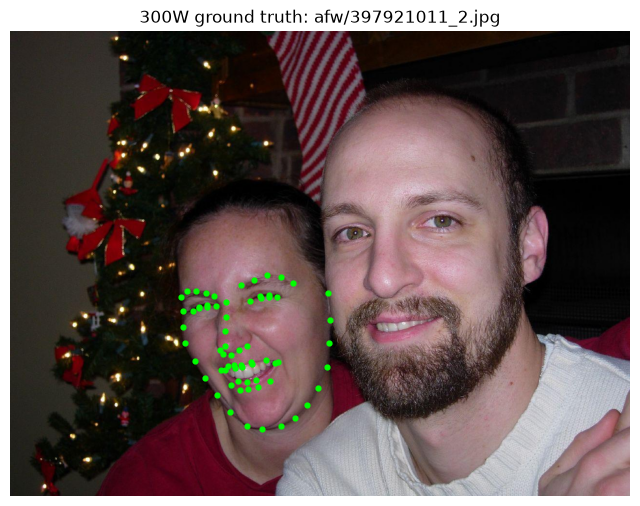

In [11]:
sample_info = None
sample_annotation = None
if DATA_READY:
    train_data = json.loads(
        (DATA_ROOT / "annotations" / ANNOTATION_FILES["train"]).read_text(encoding="utf-8")
    )
    images_by_id = {image["id"]: image for image in train_data["images"]}
    sample_annotation = train_data["annotations"][0]
    sample_info = images_by_id[sample_annotation["image_id"]]
    sample_path = DATA_ROOT / "images" / sample_info["file_name"]
    sample_image = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
    ground_truth = np.asarray(sample_annotation["keypoints"], dtype=np.float32).reshape(-1, 3)

    plt.figure(figsize=(8, 8))
    plt.imshow(sample_image)
    plt.scatter(ground_truth[:, 0], ground_truth[:, 1], s=12, c="lime")
    plt.title(f"300W ground truth: {sample_info['file_name']}")
    plt.axis("off")
else:
    print("请先准备数据")

## 4.2 HRNetV2-W18 配置

项目配置继承 MMPose 官方 60 epoch 配置，但将训练改为单 GPU、batch size 16、低学习率和 1 epoch 微调

In [18]:
from pathlib import Path

from mmengine.config import Config
from mmpose.utils import register_all_modules

register_all_modules()

LOCAL_CHECKPOINT = (
    PROJECT_ROOT
    / "checkpoints"
    / "hrnetv2_w18_300w_256x256-eea53406_20211019.pth"
)


DEFAULT_CHECKPOINT = (
    LOCAL_CHECKPOINT if LOCAL_CHECKPOINT.exists()
    else OFFICIAL_CHECKPOINT
)


def build_config(
    validation_file=ANNOTATION_FILES["full"],
    checkpoint=None,
):
    config = Config.fromfile(CONFIG_PATH)
    config.work_dir = str(WORK_DIR)
    config.load_from = str(checkpoint or DEFAULT_CHECKPOINT)


    config.train_dataloader.num_workers = 0
    config.train_dataloader.persistent_workers = False
    config.train_dataloader.dataset.data_root = str(DATA_ROOT)
    config.train_dataloader.dataset.ann_file = (
        "annotations/" + ANNOTATION_FILES["train"]
    )
    config.train_dataloader.dataset.data_prefix = dict(img="images/")

    for loader_name in ("val_dataloader", "test_dataloader"):
        loader = getattr(config, loader_name)
        loader.num_workers = 0
        loader.persistent_workers = False
        loader.batch_size = 32

        loader.dataset.data_root = str(DATA_ROOT)
        loader.dataset.ann_file = "annotations/" + validation_file
        loader.dataset.data_prefix = dict(img="images/")

    return config


cfg = build_config()

assert cfg.train_cfg.max_epochs == 1

print("模型:", cfg.model.type, "/", cfg.model.backbone.type)
print("输出关键点:", cfg.model.head.out_channels)
print("训练轮数:", cfg.train_cfg.max_epochs)
print("训练 Batch size:", cfg.train_dataloader.batch_size)
print("评估 Batch size:", cfg.test_dataloader.batch_size)
print("学习率:", cfg.optim_wrapper.optimizer.lr)
print("初始化权重:", cfg.load_from)
print("使用本地权重:", LOCAL_CHECKPOINT.exists())

模型: TopdownPoseEstimator / HRNet
输出关键点: 68
训练轮数: 1
训练 Batch size: 16
评估 Batch size: 32
学习率: 0.0001
初始化权重: D:\InternProject\face-vision-lab\checkpoints\hrnetv2_w18_300w_256x256-eea53406_20211019.pth
使用本地权重: True


### 官方权重基线评估

In [19]:
from mmengine.runner import Runner

RUN_BASELINE_EVALUATION = True

if RUN_BASELINE_EVALUATION:
    assert DATA_READY, "300W 数据尚未准备"

    test_cfg = build_config()

    test_cfg.test_dataloader.num_workers = 0
    test_cfg.test_dataloader.persistent_workers = False
    test_cfg.test_dataloader.batch_size = 32

    baseline_metrics = Runner.from_cfg(test_cfg).test()
    print("官方权重 Full NME:", baseline_metrics)

08/14 21:25:38 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1525297795
    GPU 0: NVIDIA GeForce RTX 3080
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 192930151
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


08/14 21:25:38 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/14 21:25:38 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/300w.py" does not exist. A matched config file "d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\.mim\configs\_base_\datasets\300w.py" will be used instead.
  warnings.warn(


Loads checkpoint by local backend from path: D:\InternProject\face-vision-lab\checkpoints\hrnetv2_w18_300w_256x256-eea53406_20211019.pth
08/14 21:25:39 - mmengine - INFO - Load checkpoint from D:\InternProject\face-vision-lab\checkpoints\hrnetv2_w18_300w_256x256-eea53406_20211019.pth


d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\transforms\common_transforms.py:71: UserWarning: Use the existing "bbox_center" and "bbox_scale". The padding will still be applied.
  warnings.warn('Use the existing "bbox_center" and "bbox_scale"'


08/14 21:25:57 - mmengine - INFO - Evaluating NME...
08/14 21:25:57 - mmengine - INFO - Epoch(test) [22/22]    NME: 0.034505  data_time: 0.602029  time: 0.832110
官方权重 Full NME: {'NME': 0.034504847044950056}


### 单轮微调

确认数据和 GPU 环境后，将 `RUN_TRAINING` 改为 `True`。训练完成后会自动保存 `epoch_1.pth` 和最佳 NME 检查点。

In [21]:
RUN_TRAINING = True

if RUN_TRAINING:
    assert DATA_READY, "300W 数据尚未准备"

    train_cfg = build_config()

    print("训练轮数:", train_cfg.train_cfg.max_epochs)
    print("初始化权重:", train_cfg.load_from)
    print("训练结果目录:", train_cfg.work_dir)

    runner = Runner.from_cfg(train_cfg)
    runner.train()
else:
    print("跳过训练")

训练轮数: 1
初始化权重: D:\InternProject\face-vision-lab\checkpoints\hrnetv2_w18_300w_256x256-eea53406_20211019.pth
训练结果目录: D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w
08/14 21:27:15 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1584732535
    GPU 0: NVIDIA GeForce RTX 3080
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 192930151
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVC

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


08/14 21:27:16 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/14 21:27:16 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/300w.py" does not exist. A matched config file "d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\.mim\configs\_base_\datasets\300w.py" will be used instead.
  warnings.warn(



creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
08/14 21:27:16 - mmengine - WARNING - The prefix is not set in metric class NME.
08/14 21:27:17 - mmengine - INFO - load model from: open-mmlab://msra/hrnetv2_w18
08/14 21:27:17 - mmengine - INFO - Loads checkpoint by openmmlab backend from path: open-mmlab://msra/hrnetv2_w18


Downloading: "https://download.openmmlab.com/pretrain/third_party/hrnetv2_w18-00eb2006.pth" to C:\Users\xjyy/.cache\torch\hub\checkpoints\hrnetv2_w18-00eb2006.pth


08/14 21:32:45 - mmengine - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: incre_modules.0.0.conv1.weight, incre_modules.0.0.bn1.weight, incre_modules.0.0.bn1.bias, incre_modules.0.0.bn1.running_mean, incre_modules.0.0.bn1.running_var, incre_modules.0.0.bn1.num_batches_tracked, incre_modules.0.0.conv2.weight, incre_modules.0.0.bn2.weight, incre_modules.0.0.bn2.bias, incre_modules.0.0.bn2.running_mean, incre_modules.0.0.bn2.running_var, incre_modules.0.0.bn2.num_batches_tracked, incre_modules.0.0.conv3.weight, incre_modules.0.0.bn3.weight, incre_modules.0.0.bn3.bias, incre_modules.0.0.bn3.running_mean, incre_modules.0.0.bn3.running_var, incre_modules.0.0.bn3.num_batches_tracked, incre_modules.0.0.downsample.0.weight, incre_modules.0.0.downsample.1.weight, incre_modules.0.0.downsample.1.bias, incre_modules.0.0.downsample.1.running_mean, incre_modules.0.0.downsample.1.running_var, incre_modules.0.0.downsample.1.num_batches_tracked, inc

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\transforms\common_transforms.py:71: UserWarning: Use the existing "bbox_center" and "bbox_scale". The padding will still be applied.
  warnings.warn('Use the existing "bbox_center" and "bbox_scale"'


08/14 21:33:17 - mmengine - INFO - Epoch(train) [1][ 50/197]  lr: 1.000000e-04  eta: 0:01:33  time: 0.634799  data_time: 0.444465  memory: 2720  loss: 0.000338  loss_kpt: 0.000338  acc_pose: 0.980637
08/14 21:33:48 - mmengine - INFO - Epoch(train) [1][100/197]  lr: 1.000000e-04  eta: 0:01:01  time: 0.625558  data_time: 0.451281  memory: 2720  loss: 0.000330  loss_kpt: 0.000330  acc_pose: 0.981618
08/14 21:34:18 - mmengine - INFO - Epoch(train) [1][150/197]  lr: 1.000000e-04  eta: 0:00:29  time: 0.591157  data_time: 0.417208  memory: 2720  loss: 0.000322  loss_kpt: 0.000322  acc_pose: 1.000000
08/14 21:34:48 - mmengine - INFO - Exp name: hrnetv2_w18_300w_20260814_212715
08/14 21:34:48 - mmengine - INFO - Saving checkpoint at 1 epochs
08/14 21:35:01 - mmengine - INFO - Evaluating NME...
08/14 21:35:01 - mmengine - INFO - Epoch(val) [1][22/22]    NME: 0.034686  data_time: 0.394175  time: 0.569863
08/14 21:35:01 - mmengine - INFO - The best checkpoint with 0.0347 NME at 1 epoch is saved to

### Full / Common / Challenge NME

NME（Normalized Mean Error）越低越好。Common 主要包含常规样本，Challenge 包含更困难的姿态、表情或成像条件。

In [22]:
checkpoint_candidates = (
    sorted(WORK_DIR.glob("best_NME_epoch_*.pth"))
    + sorted(WORK_DIR.glob("epoch_1.pth"))
)
FINE_TUNED_CHECKPOINT = checkpoint_candidates[0] if checkpoint_candidates else None
print("微调检查点：", FINE_TUNED_CHECKPOINT or "尚未生成")

微调检查点： D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth


In [23]:
metrics_by_split = {}
if FINE_TUNED_CHECKPOINT:
    for split in ("full", "common", "challenge"):
        evaluation_cfg = build_config(
            validation_file=ANNOTATION_FILES[split],
            checkpoint=FINE_TUNED_CHECKPOINT,
        )
        metrics_by_split[split] = Runner.from_cfg(evaluation_cfg).test()
        print(split, metrics_by_split[split])
else:
    print("请先完成训练并生成检查点")

08/14 21:44:42 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 814823529
    GPU 0: NVIDIA GeForce RTX 3080
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.1.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 192930151
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;a

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


08/14 21:44:43 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/14 21:44:43 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/300w.py" does not exist. A matched config file "d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\.mim\configs\_base_\datasets\300w.py" will be used instead.
  warnings.warn(


Loads checkpoint by local backend from path: D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth
08/14 21:44:43 - mmengine - INFO - Load checkpoint from D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth


...

08/14 21:45:09 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
08/14 21:45:09 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/300w.py" does not exist. A matched config file "d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\.mim\configs\_base_\datasets\300w.py" will be used instead.
  warnings.warn(


Loads checkpoint by local backend from path: D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth
08/14 21:45:10 - mmengine - INFO - Load checkpoint from D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth


d:\InternProject\face-vision-lab\.venv\Lib\site-packages\mmpose\datasets\transforms\common_transforms.py:71: UserWarning: Use the existing "bbox_center" and "bbox_scale". The padding will still be applied.
  warnings.warn('Use the existing "bbox_center" and "bbox_scale"'


08/14 21:45:11 - mmengine - INFO - Evaluating NME...
08/14 21:45:11 - mmengine - INFO - Epoch(test) [5/5]    NME: 0.056236  data_time: 0.198673  time: 0.373948
challenge {'NME': 0.05623551246127791}


### Loss 与 NME 曲线

由于只训练 1 epoch，NME 图只有一个验证点；Loss 曲线仍可用于确认训练是否稳定下降。

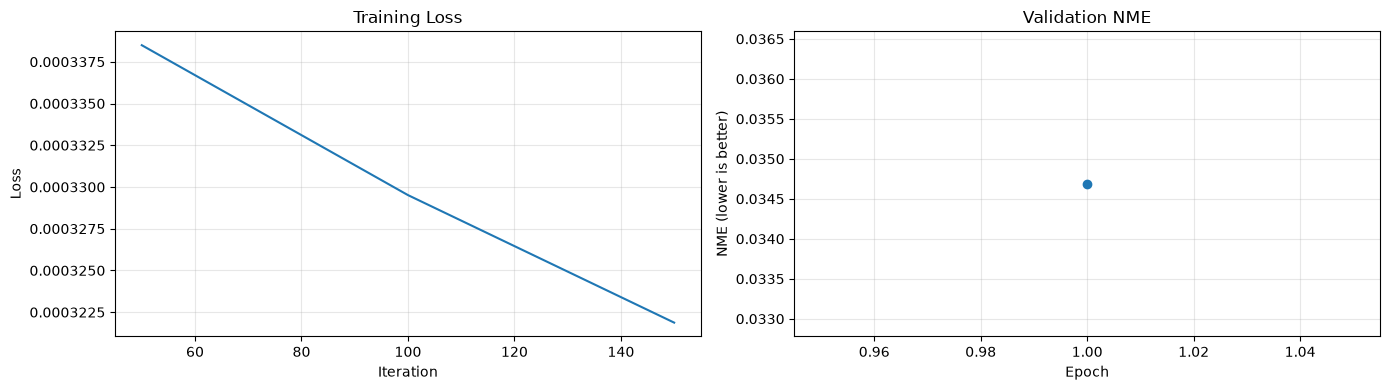

In [24]:
scalar_files = sorted(WORK_DIR.glob("*/vis_data/scalars.json"), key=lambda path: path.stat().st_mtime)
if scalar_files:
    records = [json.loads(line) for line in scalar_files[-1].read_text(encoding="utf-8").splitlines()]
    loss_points = [(row.get("step", index), row["loss"]) for index, row in enumerate(records) if "loss" in row]
    nme_points = [(row.get("step", index), row["NME"]) for index, row in enumerate(records) if "NME" in row]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if loss_points:
        axes[0].plot(*zip(*loss_points))
    axes[0].set(title="Training Loss", xlabel="Iteration", ylabel="Loss")
    axes[0].grid(alpha=0.3)
    if nme_points:
        axes[1].plot(*zip(*nme_points), marker="o")
    axes[1].set(title="Validation NME", xlabel="Epoch", ylabel="NME (lower is better)")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
else:
    print("尚未找到训练日志")

## 关键点预测结果

使用训练后的模型在一个 300W 样本上预测 68 点，并与真实关键点叠加比较。

Loads checkpoint by local backend from path: D:\InternProject\face-vision-lab\work_dirs\hrnetv2_w18_300w\best_NME_epoch_1.pth


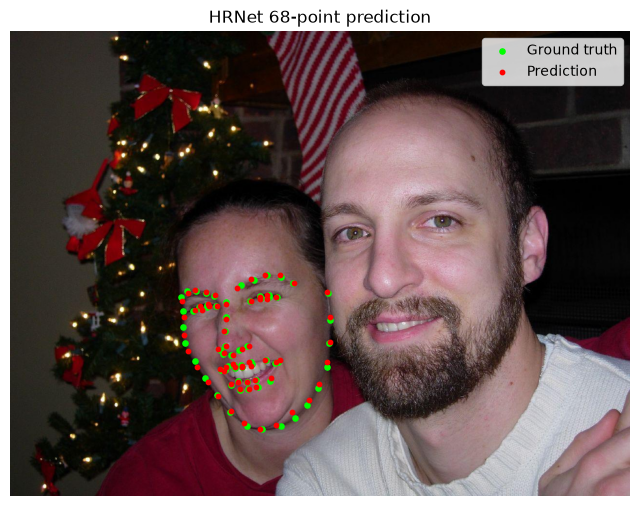

In [25]:
from mmpose.apis import inference_topdown, init_model

predicted_keypoints = None
if FINE_TUNED_CHECKPOINT and sample_annotation:
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    pose_model = init_model(str(CONFIG_PATH), str(FINE_TUNED_CHECKPOINT), device=device)
    x, y, width, height = sample_annotation["bbox"]
    bbox_xyxy = np.asarray([[x, y, x + width, y + height]], dtype=np.float32)
    prediction = inference_topdown(pose_model, str(sample_path), bboxes=bbox_xyxy)[0]
    predicted_keypoints = prediction.pred_instances.keypoints[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(sample_image)
    plt.scatter(ground_truth[:, 0], ground_truth[:, 1], s=14, c="lime", label="Ground truth")
    plt.scatter(predicted_keypoints[:, 0], predicted_keypoints[:, 1], s=10, c="red", label="Prediction")
    plt.legend()
    plt.title("HRNet 68-point prediction")
    plt.axis("off")
else:
    print("请先完成训练并运行标注检查 Cell")

## 4.3 仿射人脸对齐

从 68 点中计算左右眼中心，并取鼻尖、左右嘴角组成五个稳定点。`estimateAffinePartial2D` 估计包含旋转、缩放和平移的相似仿射变换，再将人脸映射到 256 × 256 标准模板。

In [26]:
def extract_five_points(points):
    points = np.asarray(points, dtype=np.float32)
    if points.shape != (68, 2):
        raise ValueError(f"Expected 68x2 keypoints, got {points.shape}")
    return np.asarray([
        points[36:42].mean(axis=0),
        points[42:48].mean(axis=0),
        points[30],
        points[48],
        points[54],
    ], dtype=np.float32)

TARGET_FIVE_POINTS = np.asarray([
    [80, 95], [176, 95], [128, 140], [96, 190], [160, 190]
], dtype=np.float32)

assert extract_five_points(np.zeros((68, 2), dtype=np.float32)).shape == (5, 2)
print("五点提取自检通过")

五点提取自检通过


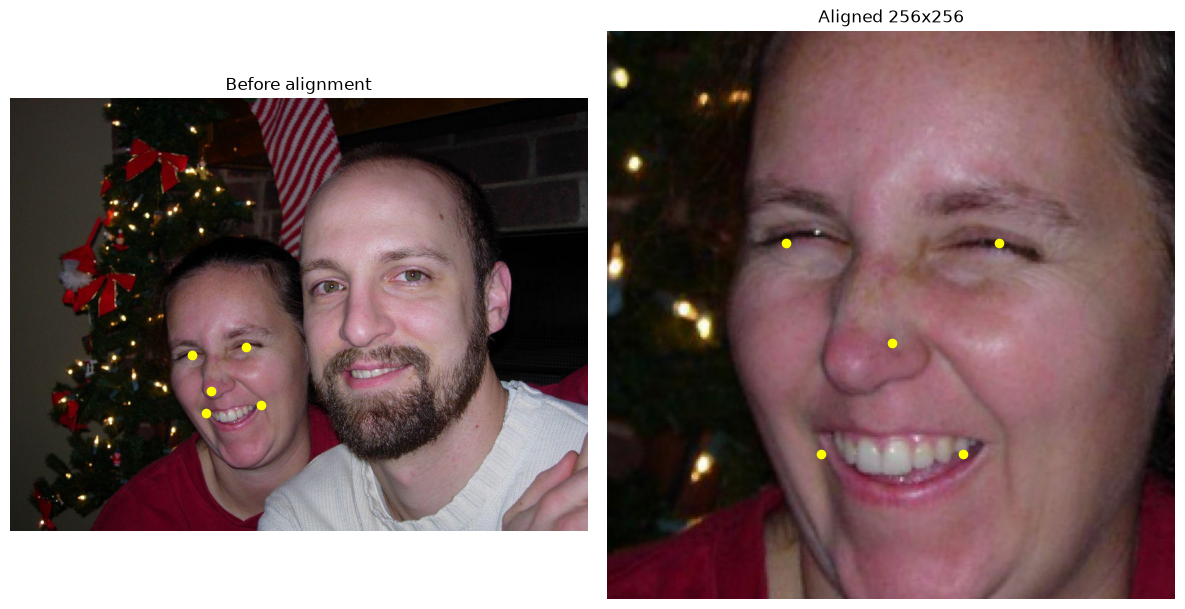

In [27]:
if predicted_keypoints is not None:
    source_five_points = extract_five_points(predicted_keypoints)
    affine_matrix, _ = cv2.estimateAffinePartial2D(
        source_five_points, TARGET_FIVE_POINTS, method=cv2.LMEDS
    )
    assert affine_matrix is not None, "无法估计仿射矩阵"
    original_bgr = cv2.imread(str(sample_path))
    aligned_bgr = cv2.warpAffine(original_bgr, affine_matrix, (256, 256))

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(sample_image)
    axes[0].scatter(source_five_points[:, 0], source_five_points[:, 1], c="yellow", s=35)
    axes[0].set_title("Before alignment")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB))
    axes[1].scatter(TARGET_FIVE_POINTS[:, 0], TARGET_FIVE_POINTS[:, 1], c="yellow", s=35)
    axes[1].set_title("Aligned 256x256")
    axes[1].axis("off")
    plt.tight_layout()
else:
    print("请先生成关键点预测")

## 实验结论（运行后填写）

- Full NME：**0.034686**
- Common NME：**0.029434**
- Challenge NME：**0.056236**
- 关键点定位表现：预测的 68 个关键点与真值整体高度重合，眼部、鼻部和嘴部定位较稳定，脸部轮廓边缘的偏差相对更明显
- 对齐效果：基于双眼中心、鼻尖和左右嘴角的五点仿射变换，人脸已对齐到 256 × 256 标准模板，五个基准点位置符合预期
- 主要失败原因：大姿态、夸张表情、近闭眼、遮挡和模糊会降低定位稳定性，尤其容易影响脸部轮廓和边界模糊点；只微调 1 epoch 也限制了模型对困难样本的进一步适应

受计算资源限制，本实验只微调 1 epoch。最终结果用于验证关键点训练、NME 评估和人脸对齐流程，不代表模型充分收敛后的最佳性能

## 参考资料

1. Wang et al., [Deep High-Resolution Representation Learning for Visual Recognition](https://arxiv.org/abs/1908.07919), TPAMI 2020.
2. Dong et al., [Style Aggregated Network for Facial Landmark Detection](https://openaccess.thecvf.com/content_cvpr_2018/html/Dong_Style_Aggregated_Network_CVPR_2018_paper.html), CVPR 2018.
3. [MMPose 300W 数据说明](https://mmpose.readthedocs.io/en/dev-1.x/dataset_zoo/2d_face_keypoint.html)
4. [MMPose HRNetV2-W18 300W 配置](https://github.com/open-mmlab/mmpose/blob/v1.3.2/configs/face_2d_keypoint/topdown_heatmap/300w/td-hm_hrnetv2-w18_8xb64-60e_300w-256x256.py)